In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'DISK1 (1)',
 'DISK1',
 'Classroom',
 'Lecture 1 -- Listening Skills.gdoc',
 'UNIT 3 - CEMENT & POP (1).gdoc',
 'IR.gdoc',
 'NewDoc07-23-202410.28.gdoc',
 'Screenshot 2024-09-23 232453.png',
 'Bubble Sort (3).gdoc',
 'Bubble Sort (2).gdoc',
 'Bubble Sort (1).gdoc',
 'Bubble Sort.gdoc',
 'Counting Sort.gdoc',
 'W1.gslides',
 'W7.L1.gslides',
 'WhatsApp Image 2024-11-22 at 4.21.57 PM.jpeg',
 'python-01.pdf',
 'python-02.pdf',
 'MYRESUME.may.docx',
 'Document from Vidhi Sharma',
 'Screenshot 2025-06-02 121603.png',
 'Screenshot 2025-06-02 121632.png',
 'Event Registration.gform',
 'Vidhi_RESUME.docx',
 'AI Framework for Sustainable Packaging Design and Material Optimization .pdf',
 'archive (2).zip',
 'archive (3).zip',
 'archive (1).zip',
 'Screenshot_2026-02-10-10-37-20-41_40deb401b9ffe8e1df2f1cc5ba480b12.jpg',
 'Screenshot 2026-02-17 120337.png',
 'Screenshot 2026-02-17 120357.png',
 'Satellite dataset.zip']

In [ ]:
!cp "/content/drive/MyDrive/Satellite dataset.zip" /content/

In [ ]:
import zipfile

with zipfile.ZipFile('/content/Satellite dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [ ]:
os.listdir('/content/')

['.config',
 'Satellite dataset.zip',
 'EuroSAT',
 'drive',
 'EuroSATallBands',
 'sample_data']

In [ ]:
import shutil
import random

In [ ]:

dataset_path = '/content/EuroSAT'
output_path = '/content/split_data'

train_path = os.path.join(output_path, 'train')
test_path = os.path.join(output_path, 'test')
val_path = os.path.join(output_path, 'val')

In [ ]:

for path in [train_path, test_path, val_path]:
    os.makedirs(path, exist_ok=True)

In [ ]:

classes = os.listdir(dataset_path)

In [ ]:
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)

    if not os.path.isdir(cls_path):
        continue

    images = os.listdir(cls_path)

    random.shuffle(images)


    total = len(images)

    train_size = int(0.7 * total)
    test_size = int(0.2 * total)

    train_imgs = images[:train_size]
    test_imgs = images[train_size:train_size + test_size]
    val_imgs = images[train_size + test_size:]

    os.makedirs(os.path.join(train_path, cls), exist_ok=True)
    os.makedirs(os.path.join(test_path, cls), exist_ok=True)
    os.makedirs(os.path.join(val_path, cls), exist_ok=True)


    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(train_path, cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(test_path, cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img),
                    os.path.join(val_path, cls, img))

    print(f"{cls} done")

print("Dataset shuffled and split successfully ✅")

Forest done
Industrial done
PermanentCrop done
SeaLake done
Residential done
Highway done
Pasture done
AnnualCrop done
HerbaceousVegetation done
River done
Dataset shuffled and split successfully ✅


In [ ]:
folders = ['train', 'test', 'val']

for f in folders:
    os.rename(f'/content/split_data/{f}/River',
              f'/content/split_data/{f}/water_bodies')

In [ ]:
base_path = '/content/split_data'

for split in ['train', 'test', 'val']:
    total = 0
    split_path = os.path.join(base_path, split)

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            total += len(os.listdir(cls_path))

    print(f"{split.upper()} total images: {total}")

TRAIN total images: 18900
TEST total images: 5400
VAL total images: 2700


In [ ]:
for split in ['train', 'test', 'val']:
    print(f"\n{split.upper()}:\n")

    split_path = f'/content/split_data/{split}'

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)

        if os.path.isdir(cls_path):
            print(f"{cls}: {len(os.listdir(cls_path))}")


TRAIN:

Forest: 2100
Industrial: 1750
water_bodies: 1750
PermanentCrop: 1750
SeaLake: 2100
Residential: 2100
Highway: 1750
Pasture: 1400
AnnualCrop: 2100
HerbaceousVegetation: 2100

TEST:

Forest: 600
Industrial: 500
water_bodies: 500
PermanentCrop: 500
SeaLake: 600
Residential: 600
Highway: 500
Pasture: 400
AnnualCrop: 600
HerbaceousVegetation: 600

VAL:

Forest: 300
Industrial: 250
water_bodies: 250
PermanentCrop: 250
SeaLake: 300
Residential: 300
Highway: 250
Pasture: 200
AnnualCrop: 300
HerbaceousVegetation: 300


In [ ]:
total_images = 0

for split in ['train', 'test', 'val']:
    for cls in os.listdir(f'/content/split_data/{split}'):
        total_images += len(os.listdir(f'/content/split_data/{split}/{cls}'))

print("Total images after split:", total_images)

Total images after split: 27000


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128,128)
BATCH_SIZE = 16

train_gen = ImageDataGenerator(rescale=1./255)

val_gen = ImageDataGenerator(rescale=1./255)

test_gen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_path,

    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 18900 images belonging to 10 classes.
Found 2700 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

Build Model


In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(train_data.num_classes, activation='softmax')(x)

eff_model = models.Model(inputs=base_model.input, outputs=output)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Compile

In [ ]:
eff_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

eff_history = eff_model.fit(
    train_data,
    validation_data=val_data,
    epochs=6,   # safe number
    callbacks=[early_stop]
)

Epoch 1/6


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1182/1182 ━━━━━━━━━━━━━━━━━━━━ 259s 212ms/step - accuracy: 0.1101 - loss: 2.3188 - val_accuracy: 0.1111 - val_loss: 2.2953
Epoch 2/6
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 253s 214ms/step - accuracy: 0.1134 - loss: 2.2955 - val_accuracy: 0.1111 - val_loss: 2.2948
Epoch 3/6
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 238s 201ms/step - accuracy: 0.1097 - loss: 2.2957 - val_accuracy: 0.1111 - val_loss: 2.2948
Epoch 4/6
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 273s 211ms/step - accuracy: 0.1095 - loss: 2.2958 - val_accuracy: 0.1111 - val_loss: 2.2948
Epoch 5/6
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 265s 225ms/step - accuracy: 0.1090 - loss: 2.2953 - val_accuracy: 0.1111 - val_loss: 2.2949
Epoch 6/6
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 251s 212ms/step - accuracy: 0.1125 - loss: 2.2954 - val_accuracy: 0.1111 - val_loss: 2.2948


Evaluate

In [ ]:
eff_loss, eff_acc = eff_model.evaluate(test_data)
print("EfficientNet Accuracy:", eff_acc)

338/338 ━━━━━━━━━━━━━━━━━━━━ 66s 196ms/step - accuracy: 0.1431 - loss: 2.2516
EfficientNet Accuracy: 0.1111111119389534


In [ ]:
eff_model.save('/content/efficientnet_model.keras')

In [ ]:
import numpy as np

y_true = test_data.classes
y_pred_prob = eff_model.predict(test_data)
y_pred = np.argmax(y_pred_prob, axis=1)

338/338 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    mean_squared_error,
    mean_absolute_error,
    classification_report,
    confusion_matrix
)

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
kappa = cohen_kappa_score(y_true, y_pred)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Cohen Kappa:", kappa)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

Accuracy: 0.1111111111111111
Precision: 0.012345679012345677
Recall: 0.1111111111111111
F1 Score: 0.022222222222222223
Cohen Kappa: 0.0
MSE: 14.481481481481481
RMSE: 3.8054541754541575
MAE: 3.074074074074074


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       600
           1       0.00      0.00      0.00       600
           2       0.11      1.00      0.20       600
           3       0.00      0.00      0.00       500
           4       0.00      0.00      0.00       500
           5       0.00      0.00      0.00       400
           6       0.00      0.00      0.00       500
           7       0.00      0.00      0.00       600
           8       0.00      0.00      0.00       600
           9       0.00      0.00      0.00       500

    accuracy                           0.11      5400
   macro avg       0.01      0.10      0.02      5400
weighted avg       0.01      0.11      0.02      5400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


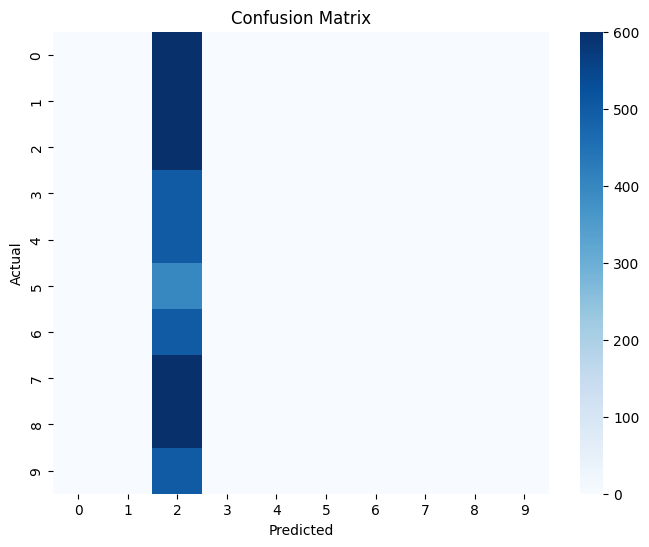

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

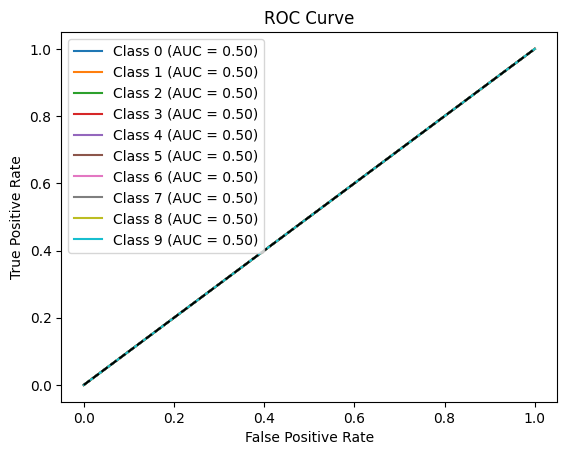

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = train_data.num_classes

y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
print(eff_model.history)

In [ ]:
import numpy as np
print(np.unique(y_pred))

[2]


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 18900 images belonging to 10 classes.
Found 2700 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


In [ ]:
from tensorflow.keras.optimizers import Adam

eff_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

TRAINING AGAIN

In [ ]:
eff_history = eff_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


591/591 ━━━━━━━━━━━━━━━━━━━━ 300s 483ms/step - accuracy: 0.5864 - loss: 1.3955 - val_accuracy: 0.9022 - val_loss: 0.3650
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 272s 460ms/step - accuracy: 0.8641 - loss: 0.4366 - val_accuracy: 0.9167 - val_loss: 0.2651
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 279s 473ms/step - accuracy: 0.8905 - loss: 0.3387 - val_accuracy: 0.9252 - val_loss: 0.2327
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 280s 474ms/step - accuracy: 0.9039 - loss: 0.2990 - val_accuracy: 0.9307 - val_loss: 0.2111
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 276s 467ms/step - accuracy: 0.9122 - loss: 0.2641 - val_accuracy: 0.9337 - val_loss: 0.2017


In [ ]:
y_pred_prob = eff_model.predict(test_data)
y_pred = np.argmax(y_pred_prob, axis=1)

print(np.unique(y_pred))

169/169 ━━━━━━━━━━━━━━━━━━━━ 75s 414ms/step
[0 1 2 3 4 5 6 7 8 9]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    mean_squared_error,
    mean_absolute_error,
    classification_report,
    confusion_matrix
)

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
kappa = cohen_kappa_score(y_true, y_pred)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Cohen Kappa:", kappa)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

Accuracy: 0.9261111111111111
Precision: 0.9262831671852437
Recall: 0.9261111111111111
F1 Score: 0.9260884379321666
Cohen Kappa: 0.9177486037571625
MSE: 1.4935185185185185
RMSE: 1.2220959530734559
MAE: 0.2972222222222222


In [ ]:
eff_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 128, 128,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 64, 64,    │        512 │ block1a_se_excit

 Total params: 5,041,091 (19.23 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 661,014 (2.52 MB)

Compile with Lower Learning Rate (0.0001)